/Users/imkerhoogenhout/Documents/Engineering/Masters/Masters_Repo/Masters/MEE_Thermo_Func.py:30: RuntimeWarning: invalid value encountered in scalar power
  return 2889 * (1 - Tr) ** (0.3199 - 0.212 * Tr + 0.25795 * Tr ** 2)


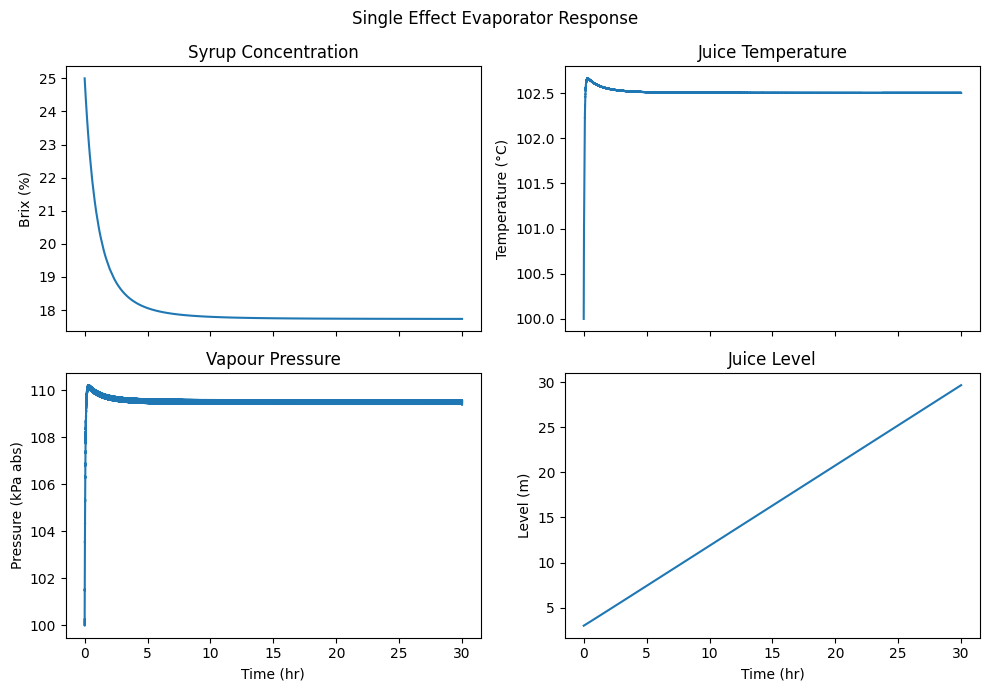

In [ ]:
# MEE Model based on Smith (2000)

import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
from MEE_Thermo_Func import fP_eq, fT_eq, f_PJ_eq, fh, fdhvap, fh_ev, fcP, frho

# Parameters
R = 8.314 * (1e3 / 18)
alpha = 1e2
U = 1500 * 3600 / 1e6

Dves = 5.5
Vol = 120
CrossA = np.pi * Dves**2 / 4
Ntubes = 7550
Ltubes = 2
Dtubes = 42e-3
A = Ntubes * Ltubes * np.pi * Dtubes / 2

# Evaporator Inputs/Variables
x = 1
P_upstream = 121.95
Vdraw_total = 5
FJ_in = 78.5
Bx_in = 16.6
TJ_in = 95.5

FJ_out = 52

class Evaporator:
    def __init__(self, FJ_in, Bx_in, TJ_in, FJ_out):
        
        self.FJ_in = FJ_in
        self.Bx_in = Bx_in
        self.TJ_in = TJ_in
        self.FJ_out = FJ_out

    def ODEs(self, t, y):
        
        Bx, TJ, P, LJ = y

        mJ = LJ * frho(TJ, Bx) * CrossA
        Vev = alpha * (f_PJ_eq(TJ, Bx) - P)
        PST = x * P_upstream + (1 - x) * fP_eq(TJ)
        TST = fT_eq(PST)
        Q = U * A * (TST - TJ)

        
        dmJ_dt = self.FJ_in - self.FJ_out - Vev
        dLJ_dt = dmJ_dt / (frho(TJ, Bx) * CrossA)
        dBx_dt = (self.FJ_in * self.Bx_in - self.FJ_out * Bx - Bx * dmJ_dt) / mJ
        dTJ_dt = (self.FJ_in * fh(self.TJ_in, self.Bx_in)
                  - self.FJ_out * fh(TJ, Bx)
                  - Vev * fh_ev(TJ, Bx) + Q) / (mJ * fcP(TJ, Bx)) \
                 - TJ * dmJ_dt / mJ
        dP_dt = (R * TJ / Vol) * (Vev - Vdraw_total) + P / TJ * dTJ_dt

        return [dBx_dt, dTJ_dt, dP_dt, dLJ_dt]


y0 = [25, 100, 100.25, 3]  # [Bx, TJ, P, LJ]

t_span = (0, 30)

evaporator = Evaporator(FJ_in, Bx_in, TJ_in, FJ_out)
solution = solve_ivp(evaporator.ODEs, t_span, y0, method='RK45')

Bx_sol, TJ_sol, P_sol, LJ_sol = solution.y

fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharex=True)

axes[0, 0].plot(solution.t, Bx_sol)
axes[0, 0].set_ylabel('Brix (%)')
axes[0, 0].set_title('Syrup Concentration')

axes[0, 1].plot(solution.t, TJ_sol)
axes[0, 1].set_ylabel('Temperature (°C)')
axes[0, 1].set_title('Juice Temperature')

axes[1, 0].plot(solution.t, P_sol)
axes[1, 0].set_ylabel('Pressure (kPa abs)')
axes[1, 0].set_title('Vapour Pressure')
axes[1, 0].set_xlabel('Time (hr)')

axes[1, 1].plot(solution.t, LJ_sol)
axes[1, 1].set_ylabel('Level (m)')
axes[1, 1].set_title('Juice Level')
axes[1, 1].set_xlabel('Time (hr)')

fig.suptitle('Single Effect Evaporator Response')
fig.tight_layout()
plt.show()